# Pipeline de treinamento de um modelo de deep learning
## Detecção de COVID-19 em tomografias computadorizadas (CT) do pulmão

Neste notebook vamos construir, passo a passo, o **pipeline completo de treinamento de um modelo de deep learning** para imagens médicas. O objetivo: dada uma **tomografia computadorizada (CT) do pulmão**, o modelo deve dizer se o caso é **positivo para COVID-19** ou **normal**.

O caminho que vamos percorrer é o de qualquer projeto de visão computacional:

```
imagens de tomografia (CT)
   → divisão em treino / validação / teste
   → carregamento, aumento de dados e normalização
   → modelo pré-treinado (VGG16) + nova "cabeça"
   → treino em 2 fases
   → avaliação no teste
   → previsão de uma imagem nova
```

| Conceito | O que é |
|---|---|
| **Deep learning** | Redes neurais com muitas camadas que aprendem padrões diretamente dos dados (aqui, dos pixels das imagens). |
| **Rede convolucional (CNN)** | Tipo de rede especializada em imagens: aprende a reconhecer bordas, texturas e formas. |
| **Transfer learning** | Reaproveitar uma rede já treinada em milhões de imagens (ImageNet) e adaptá-la ao nosso problema, que tem poucas imagens. |
| **Treino / validação / teste** | Três conjuntos separados: um para aprender, um para acompanhar o aprendizado e um para a prova final. |

> ⚠️ **Aviso:** este é um **exemplo didático**. Um modelo treinado com algumas centenas de imagens **não serve para diagnóstico médico**.

## 0. Como rodar este notebook

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pasteurjr/notebookvideoaulas/blob/main/03_deep_learning_covid_ct/notebook/pipeline_treinamento_covid_ct.ipynb)

O curso tem duas partes, com a **mesma estrutura de pastas** (uma pasta por aula):

| O quê | Onde |
|---|---|
| **Código**: os notebooks e os arquivos que eles usam | GitHub: **https://github.com/pasteurjr/notebookvideoaulas** |
| **Dados, vídeos e roteiros** de cada aula | Google Drive: **[pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)** |

**Antes de começar, leia o [README.md da pasta do Google Drive](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing)**: ele explica como baixar e organizar os dados de todas as aulas.

**Esta aula (`03_deep_learning_covid_ct`) usa:** a pasta **`dados/`** do Google Drive: as tomografias de COVID-19 e a divisão em treino, validação e teste (~190 MB); **GPU** (no Colab, a T4 gratuita é suficiente); nenhuma chave de API.

### Opção A: Google Colab (recomendado)

1. **Coloque os dados do curso no seu Google Drive** (uma vez só, vale para todas as aulas). Abra a [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) do curso, **baixe** a pasta e faça o **upload** dela para o seu **Meu Drive**, mantendo o nome e as subpastas. Os dados desta aula precisam ficar em **`MyDrive/notebooksvideos/03_deep_learning_covid_ct/notebook/dados`**. Mais rápido: em vez de baixar e subir, clique com o botão direito na pasta → **Organizar → Adicionar atalho** → **Meu Drive**.
2. **Abra este notebook no Colab** pelo botão **Abrir no Colab** acima (ele abre direto do GitHub).
3. **Ative a GPU gratuita:** **Ambiente de execução → Alterar o tipo de ambiente de execução → GPU T4**.
4. **Rode a célula de preparação logo abaixo.** Ela clona o repositório do GitHub para o Colab, monta o seu Google Drive (autorize o acesso), copia os dados desta aula e instala só as bibliotecas que faltarem.
5. Depois: **Ambiente de execução → Executar tudo**.

**Se aparecer erro de biblioteca** (`ModuleNotFoundError`, `ImportError` ou erro de versão): crie uma célula nova, rode o comando abaixo, depois vá em **Ambiente de execução → Reiniciar sessão** e rode a célula de preparação de novo.

```
!pip install tensorflow keras scikit-learn matplotlib pillow
```

### Opção B: no seu computador

Basta baixar. Pré-requisito: [Miniconda](https://docs.conda.io/en/latest/miniconda.html) (ou Anaconda) e Git. No terminal:

```bash
git clone https://github.com/pasteurjr/notebookvideoaulas.git
cd notebookvideoaulas
conda create -n notecursos python=3.12 -y
conda activate notecursos
pip install -r requirements.txt
cd 03_deep_learning_covid_ct/notebook
jupyter notebook pipeline_treinamento_covid_ct.ipynb
```

**Dados:** baixe da [pasta notebooksvideos](https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta **`03_deep_learning_covid_ct/notebook/dados`** e coloque em `notebookvideoaulas/03_deep_learning_covid_ct/notebook/dados`.

No computador local, a célula de preparação detecta que não está no Colab e não faz nada.

### Dica: peça ajuda a um assistente de IA

Um assistente de programação, como o **Claude Code** ou o **Codex**, faz toda essa preparação sozinho. Abra o assistente numa pasta vazia e peça, por exemplo:

> Clone https://github.com/pasteurjr/notebookvideoaulas. Crie o ambiente conda `notecursos` com Python 3.12 e instale: `pip install -r requirements.txt`. Baixe da pasta notebooksvideos do Google Drive (https://drive.google.com/drive/folders/1mMRjinjohj_jyMsJzO7rxgYKm6unVKze?usp=sharing) a pasta `03_deep_learning_covid_ct/notebook/dados` e coloque em `03_deep_learning_covid_ct/notebook/dados`. Por fim, abra `03_deep_learning_covid_ct/notebook/pipeline_treinamento_covid_ct.ipynb` no Jupyter.


In [1]:
# PREPARAÇÃO DO AMBIENTE NO GOOGLE COLAB (igual em todos os notebooks do curso; no computador local não faz nada)
AULA = "03_deep_learning_covid_ct/notebook"                           # pasta desta aula no repositório
USA_DADOS_DO_DRIVE = True                                     # copia os dados da pasta "notebooksvideos" do Drive
PACOTES = {"tensorflow": "tensorflow", "keras": "keras", "sklearn": "scikit-learn", "matplotlib": "matplotlib", "PIL": "pillow"}   # módulo: pacote pip
SECRETS = []                                   # chaves lidas dos Secrets do Colab (ícone 🔑)

import os, sys, shutil, subprocess, importlib.util

if "google.colab" in sys.modules:
    # 1) Código: clona o repositório do GitHub para o Colab
    if not os.path.exists("/content/notebookvideoaulas"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pasteurjr/notebookvideoaulas.git",
                        "/content/notebookvideoaulas"], check=True)
    os.chdir(f"/content/notebookvideoaulas/{AULA}")

    # 2) Dados: copia da pasta "notebooksvideos" (atalho no Meu Drive) para a pasta da aula
    if USA_DADOS_DO_DRIVE and not os.path.exists("dados"):
        from google.colab import drive
        drive.mount("/content/drive")
        origem = f"/content/drive/MyDrive/notebooksvideos/{AULA}/dados"
        if not os.path.exists(origem):
            raise FileNotFoundError(f"Não encontrei {origem}. Coloque a pasta notebooksvideos do curso no seu Meu Drive "
                                    "(veja o README.md da pasta do Google Drive) e rode esta célula de novo.")
        shutil.copytree(origem, "dados")

    # 3) Bibliotecas: instala só as que a sessão do Colab ainda não tem
    faltando = [pip for modulo, pip in PACOTES.items() if importlib.util.find_spec(modulo) is None]
    if faltando:
        print("Instalando:", ", ".join(faltando))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *faltando], check=True)
        print("Pronto. Se o Colab pedir 'Reiniciar sessão', reinicie e rode esta célula de novo.")
    else:
        print("Todas as bibliotecas já estão instaladas no Colab.")

    # 4) Chaves de API: vêm dos Secrets do Colab (nunca escreva a chave no notebook)
    if SECRETS:
        from google.colab import userdata
        for chave in SECRETS:
            os.environ[chave] = userdata.get(chave)

    print("Pasta da aula:", os.getcwd())
    print("Conteúdo:", sorted(os.listdir(".")))
else:
    print("Ambiente local detectado: usando a pasta atual.")

Ambiente local detectado: usando a pasta atual.


## 1. Bibliotecas e verificação da GPU

Usamos três grupos de ferramentas:

- **TensorFlow / Keras**: a biblioteca de deep learning. O Keras é a "camada amigável" do TensorFlow, onde montamos e treinamos as redes.
- **scikit-learn**: métricas de avaliação (matriz de confusão, relatório de classificação).
- **matplotlib**: gráficos e visualização das imagens.

Treinar redes neurais envolve milhões de multiplicações. A **GPU** (placa de vídeo) faz essas contas em paralelo e acelera o treino em dezenas de vezes. A última linha mostra se o TensorFlow encontrou uma GPU.

`keras.utils.set_random_seed(42)` fixa a "semente" dos números aleatórios, para que os resultados sejam parecidos a cada execução.

In [2]:
import os, random, shutil, time, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # esconde as mensagens internas do TensorFlow
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")             # esconde avisos que não interessam para a aula

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU disponível:", [tf.config.experimental.get_device_details(g)["device_name"] for g in gpus] or "nenhuma (vai rodar na CPU, bem mais devagar)")

TensorFlow: 2.21.0 | Keras: 3.15.1
GPU disponível: ['NVIDIA GeForce RTX 5080']


## 2. Configurações do experimento

Todos os parâmetros ficam reunidos numa célula só, como no arquivo `config.py` dos projetos originais. Assim fica fácil experimentar.

| Parâmetro | Significado |
|---|---|
| `PASTA_ORIGINAL` | Onde estão as tomografias originais, uma subpasta por classe |
| `PASTA_DIVISAO` | Onde vamos criar as pastas de treino, validação e teste |
| `TREINO_FRACAO` / `VALIDACAO_FRACAO` | 80% das imagens para treino e 20% para teste; 10% do treino vira validação |
| `TAMANHO_IMAGEM` | A VGG16 foi criada para imagens de 224×224 pixels |
| `LOTE` (*batch*) | Quantas imagens a rede vê antes de cada ajuste dos pesos |
| `EPOCAS_*` | Uma **época** é uma passada completa por todas as imagens de treino. Estes são limites máximos: o treino para antes se parar de melhorar |
| `TAXA_*` | A **taxa de aprendizado**: o tamanho do "passo" em cada ajuste dos pesos |

In [3]:
PASTA_ORIGINAL = Path("dados/datasetct")
PASTA_DIVISAO  = Path("dados/divisao")
PASTA_MODELOS  = Path("modelos")

CLASSES = ["covid", "normal"]          # índice 0 = covid (classe positiva), índice 1 = normal

TREINO_FRACAO    = 0.80                # 80% treino (+ validação) / 20% teste
VALIDACAO_FRACAO = 0.10                # 10% do treino vira validação

TAMANHO_IMAGEM = (224, 224)
LOTE = 8

EPOCAS_FASE1 = 60                      # transfer learning (limite máximo)
EPOCAS_FASE2 = 20                      # ajuste fino (limite máximo)
TAXA_FASE1   = 1e-4
TAXA_FASE2   = 1e-5

## 3. Conhecendo os dados

Usamos o **COVID-CT**, um conjunto público de tomografias de pulmão reunido por pesquisadores da UC San Diego a partir de artigos científicos. As imagens estão separadas em duas pastas, uma por classe: **`covid`** e **`normal`**.

Antes de treinar qualquer modelo, sempre olhamos os dados: quantas imagens existem de cada classe e como elas são. Um conjunto muito desbalanceado (por exemplo, 90% de uma classe) exigiria cuidados extras. Aqui as classes estão equilibradas.

In [4]:
EXTENSOES = {".png", ".jpg", ".jpeg"}

def listar_imagens(pasta):
    return sorted(p for p in Path(pasta).rglob("*") if p.suffix.lower() in EXTENSOES)

for classe in CLASSES:
    print(f"{classe:>7}: {len(listar_imagens(PASTA_ORIGINAL / classe))} imagens")
print(f"  total: {len(listar_imagens(PASTA_ORIGINAL))} imagens")

  covid: 349 imagens
 normal: 397 imagens
  total: 746 imagens


Vejamos alguns exemplos de cada classe. Repare que as imagens têm **tamanhos e formatos diferentes** (algumas coloridas, outras em tons de cinza): mais adiante, todas serão padronizadas para 224×224 pixels em RGB.

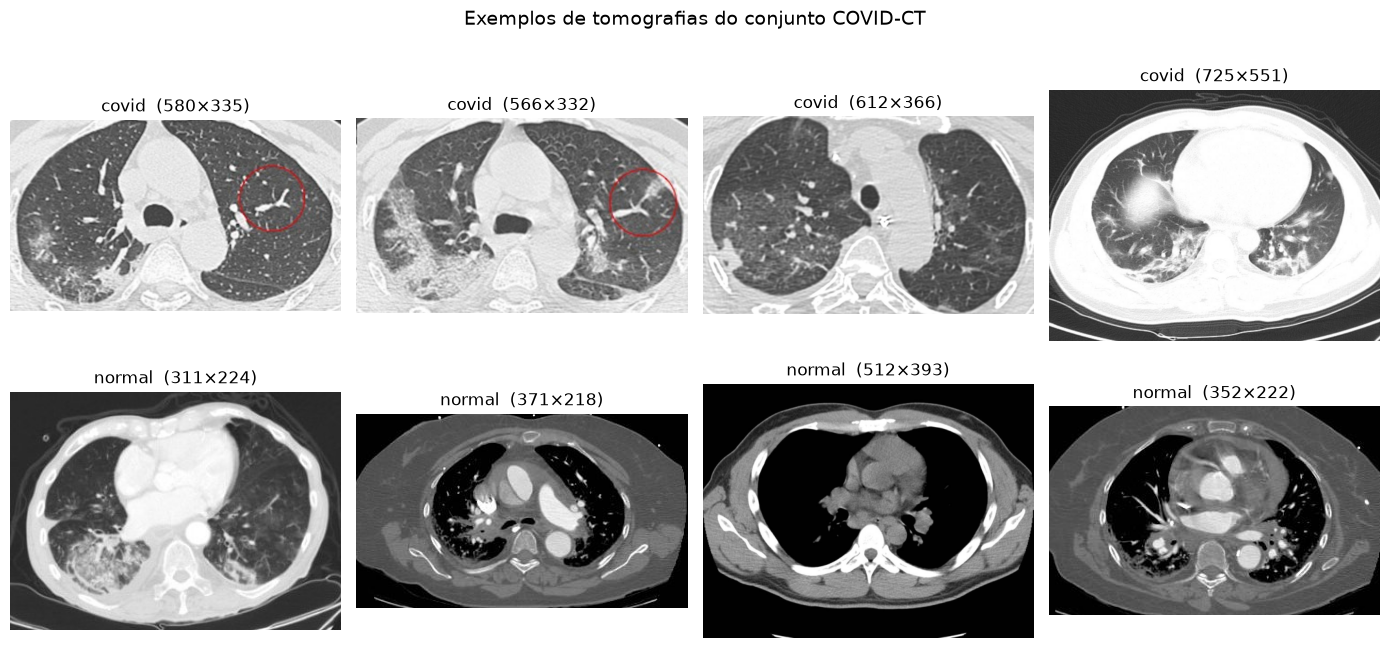

In [5]:
fig, eixos = plt.subplots(2, 4, figsize=(14, 7))
for linha, classe in enumerate(CLASSES):
    for coluna, caminho in enumerate(listar_imagens(PASTA_ORIGINAL / classe)[:4]):
        imagem = keras.utils.load_img(caminho)
        eixos[linha, coluna].imshow(imagem)
        eixos[linha, coluna].set_title(f"{classe}  ({imagem.size[0]}×{imagem.size[1]})")
        eixos[linha, coluna].axis("off")
plt.suptitle("Exemplos de tomografias do conjunto COVID-CT", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Dividindo em treino, validação e teste

Esta é uma das etapas mais importantes. Separamos as imagens em **três conjuntos que nunca se misturam**:

| Conjunto | Para que serve | Analogia |
|---|---|---|
| **Treino** | A rede aprende com estas imagens | O material de estudo |
| **Validação** | Acompanhamos o desempenho a cada época, para decidir quando parar | Os simulados |
| **Teste** | Só usado no final, para medir o desempenho real | A prova final |

Se testássemos com imagens de treino, seria como dar a prova com as mesmas questões do material de estudo: a nota seria enganosamente alta.

A função abaixo é a mesma lógica do script `build_dataset.py` dos projetos originais: embaralha as imagens com uma semente fixa (para ser reproduzível), separa 80% para treino e 20% para teste, reserva 10% do treino para validação e **copia** cada imagem para a pasta do seu conjunto e da sua classe.

In [6]:
def dividir_dataset(pasta_original, pasta_destino, treino_fracao, validacao_fracao, semente=42):
    imagens = listar_imagens(pasta_original)
    random.Random(semente).shuffle(imagens)

    corte = int(len(imagens) * treino_fracao)
    treino, teste = imagens[:corte], imagens[corte:]
    corte_val = int(len(treino) * validacao_fracao)
    validacao, treino = treino[:corte_val], treino[corte_val:]

    if Path(pasta_destino).exists():                    # recomeça do zero a cada execução
        shutil.rmtree(pasta_destino)

    for nome, lista in [("treino", treino), ("validacao", validacao), ("teste", teste)]:
        for caminho in lista:
            classe = caminho.parent.name                  # o nome da pasta é o rótulo
            destino = Path(pasta_destino) / nome / classe
            destino.mkdir(parents=True, exist_ok=True)
            shutil.copy2(caminho, destino / caminho.name)

dividir_dataset(PASTA_ORIGINAL, PASTA_DIVISAO, TREINO_FRACAO, VALIDACAO_FRACAO)

print(f"{'conjunto':<10} {'covid':>6} {'normal':>7} {'total':>6}")
for conjunto in ["treino", "validacao", "teste"]:
    n = [len(listar_imagens(PASTA_DIVISAO / conjunto / c)) for c in CLASSES]
    print(f"{conjunto:<10} {n[0]:>6} {n[1]:>7} {sum(n):>6}")

conjunto    covid  normal  total
treino        253     284    537
validacao      27      32     59
teste          69      81    150


## 5. Carregando as imagens com `tf.data`

Não carregamos todas as imagens na memória de uma vez. A função `image_dataset_from_directory` cria um **dataset** que lê as imagens do disco aos poucos, em **lotes** (*batches*) de 8, e faz o trabalho pesado para nós:

- descobre o **rótulo** de cada imagem pelo nome da pasta (`covid` ou `normal`);
- converte todas para **RGB** e redimensiona para **224×224**;
- codifica o rótulo em **one-hot**: covid vira `[1, 0]` e normal vira `[0, 1]`, o formato que a camada de saída da rede produz.

Só o conjunto de treino é embaralhado (`shuffle=True`). Validação e teste mantêm a ordem, para compararmos as previsões com os arquivos depois.

In [7]:
opcoes = dict(image_size=TAMANHO_IMAGEM, batch_size=LOTE, label_mode="categorical",
              class_names=CLASSES, color_mode="rgb")

treino_bruto    = keras.utils.image_dataset_from_directory(PASTA_DIVISAO / "treino",    shuffle=True, seed=42, **opcoes)
validacao_bruto = keras.utils.image_dataset_from_directory(PASTA_DIVISAO / "validacao", shuffle=False, **opcoes)
teste_bruto     = keras.utils.image_dataset_from_directory(PASTA_DIVISAO / "teste",     shuffle=False, **opcoes)

imagens, rotulos = next(iter(treino_bruto))
print("Formato de um lote de imagens:", imagens.shape, "→ (lote, altura, largura, canais RGB)")
print("Rótulos do lote (one-hot):", rotulos.numpy().astype(int).tolist())

Found 537 files belonging to 2 classes.


Found 59 files belonging to 2 classes.


Found 150 files belonging to 2 classes.


Formato de um lote de imagens: (8, 224, 224, 3) → (lote, altura, largura, canais RGB)
Rótulos do lote (one-hot): [[1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0]]


## 6. Aumento de dados e normalização

**Aumento de dados** (*data augmentation*): com poucas centenas de imagens, a rede corre o risco de **decorar** o conjunto de treino em vez de aprender padrões gerais (o chamado *overfitting*). Para evitar isso, a cada época mostramos versões **levemente modificadas** de cada imagem: um pouco giradas, espelhadas ou aproximadas. Para a rede, é como se tivéssemos mais imagens. Isso vale **só para o treino**.

**Normalização**: a VGG16 foi treinada no ImageNet com as imagens num formato específico (canais na ordem BGR e a média de cada canal subtraída). A função `preprocess_input` aplica exatamente essa transformação. **Esquecer esse passo** é um erro comum, e os notebooks originais deste projeto não o aplicavam, o que prejudicava os resultados.

O `prefetch` prepara o próximo lote enquanto a GPU processa o atual, para a GPU não ficar esperando.

In [8]:
aumento = keras.Sequential([
    layers.RandomRotation(15 / 360),        # gira até ±15 graus
    layers.RandomFlip("horizontal"),        # espelha horizontalmente
    layers.RandomZoom(0.1),                 # aproxima/afasta até 10%
], name="aumento_de_dados")

AUTOTUNE = tf.data.AUTOTUNE
treino    = treino_bruto.map(lambda x, y: (preprocess_input(aumento(x, training=True)), y)).prefetch(AUTOTUNE)
validacao = validacao_bruto.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
teste     = teste_bruto.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

Veja o aumento de dados em ação: a mesma tomografia, transformada 7 vezes de forma aleatória.

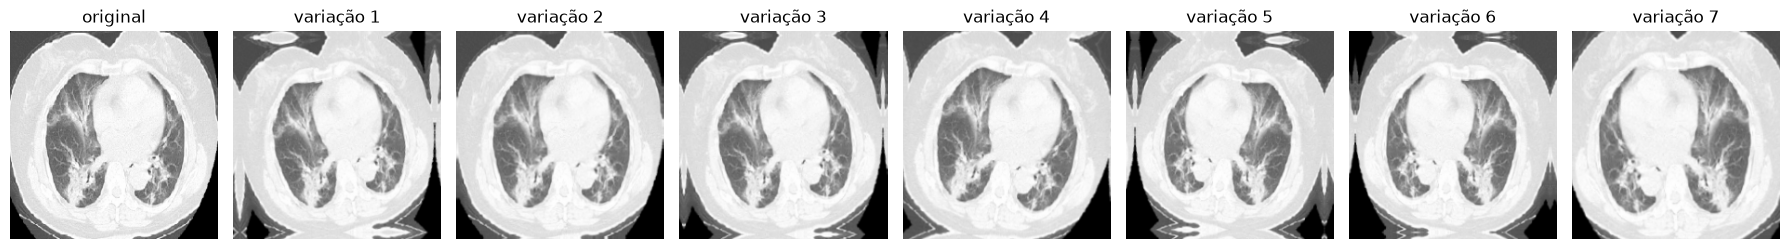

In [9]:
exemplo = imagens[0:1]
fig, eixos = plt.subplots(1, 8, figsize=(18, 3))
eixos[0].imshow(exemplo[0].numpy().astype("uint8")); eixos[0].set_title("original")
for i in range(1, 8):
    eixos[i].imshow(aumento(exemplo, training=True)[0].numpy().clip(0, 255).astype("uint8"))
    eixos[i].set_title(f"variação {i}")
for eixo in eixos: eixo.axis("off")
plt.tight_layout()
plt.show()

## 7. Transfer learning: a VGG16 pré-treinada

Treinar uma rede convolucional do zero exige dezenas de milhares de imagens. Com 537 imagens de treino, a saída é o **transfer learning**: aproveitamos a **VGG16**, uma rede com 16 camadas que já foi treinada no **ImageNet** (1,2 milhão de fotos de 1.000 categorias). As camadas convolucionais dela já sabem extrair bordas, texturas e formas, e isso é útil também em tomografias.

- `weights="imagenet"` baixa os pesos já treinados (cerca de 58 MB, só na primeira vez);
- `include_top=False` descarta a "cabeça" original, que classificava as 1.000 categorias do ImageNet;
- `base.trainable = False` **congela** a VGG16: na primeira fase de treino, os pesos dela não mudam.

> **Por que VGG16?** Comparamos a VGG16 com a ResNet50 nos treinos anteriores deste projeto: a VGG16 teve resultados mais estáveis nesse conjunto pequeno. Trocar pela ResNet50 é um bom exercício.

In [10]:
base = VGG16(weights="imagenet", include_top=False, input_shape=TAMANHO_IMAGEM + (3,))
base.trainable = False

print(f"Camadas da VGG16: {len(base.layers)}")
print(f"Parâmetros (pesos) da VGG16: {base.count_params():,}".replace(",", "."))
print("Últimas camadas:", [camada.name for camada in base.layers[-5:]])

Camadas da VGG16: 19
Parâmetros (pesos) da VGG16: 14.714.688
Últimas camadas: ['block4_pool', 'block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']


## 8. A nova "cabeça" do modelo

Sobre a VGG16 congelada colocamos uma **cabeça** nova, pequena, que vai aprender a decidir entre covid e normal a partir das características que a VGG16 extrai:

| Camada | Função |
|---|---|
| `GlobalAveragePooling2D` | Resume cada um dos 512 "mapas de características" da VGG16 num único número (a média) |
| `Dense(256, relu)` | Camada totalmente conectada que combina essas características |
| `Dropout(0.5)` | Durante o treino, desliga aleatoriamente metade dos neurônios: força a rede a não depender de poucos detalhes (combate o *overfitting*) |
| `Dense(2, softmax)` | Saída: duas probabilidades que somam 1, uma para covid e outra para normal |

No resumo, compare os **parâmetros treináveis** (só os da cabeça) com os **não treináveis** (os da VGG16 congelada).

In [11]:
entrada = keras.Input(shape=TAMANHO_IMAGEM + (3,))
x = base(entrada, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
saida = layers.Dense(len(CLASSES), activation="softmax")(x)

modelo = keras.Model(entrada, saida, name="covid_ct_vgg16")
modelo.summary()

Model: "covid_ct_vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,530 (56.64 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 9. Treinamento, fase 1: só a cabeça aprende

Antes de treinar, **compilamos** o modelo, isto é, escolhemos:

- o **otimizador** `Adam`: o algoritmo que ajusta os pesos na direção que reduz o erro;
- a **função de perda** `categorical_crossentropy`: mede o quanto as probabilidades previstas estão longe dos rótulos corretos;
- a **métrica** `accuracy`: a porcentagem de acertos, fácil de interpretar.

O **`EarlyStopping`** vigia a perda na validação: se ela não melhorar por 8 épocas seguidas, o treino para e os **melhores pesos** são restaurados. Assim, `EPOCAS_FASE1` é só um limite máximo.

Cada linha da saída é uma época: `loss`/`accuracy` no treino e `val_loss`/`val_accuracy` na validação.

In [12]:
modelo.compile(optimizer=keras.optimizers.Adam(TAXA_FASE1),
               loss="categorical_crossentropy",
               metrics=["accuracy"])

parada_antecipada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

inicio = time.time()
historico1 = modelo.fit(treino, validation_data=validacao, epochs=EPOCAS_FASE1,
                        callbacks=[parada_antecipada], verbose=2)
print(f"\nFase 1: {len(historico1.history['loss'])} épocas em {time.time() - inicio:.0f} segundos")

Epoch 1/60


68/68 - 10s - 153ms/step - accuracy: 0.5605 - loss: 2.0178 - val_accuracy: 0.6780 - val_loss: 1.0002


Epoch 2/60


68/68 - 3s - 39ms/step - accuracy: 0.6313 - loss: 1.5389 - val_accuracy: 0.7458 - val_loss: 0.7476


Epoch 3/60


...

Epoch 43/60


68/68 - 3s - 41ms/step - accuracy: 0.9106 - loss: 0.2362 - val_accuracy: 0.9322 - val_loss: 0.3202


Epoch 44/60


68/68 - 3s - 43ms/step - accuracy: 0.9125 - loss: 0.2281 - val_accuracy: 0.9153 - val_loss: 0.3266



Fase 1: 44 épocas em 130 segundos


## 10. Treinamento, fase 2: ajuste fino (*fine-tuning*)

Com a cabeça já treinada, **descongelamos o último bloco da VGG16** (as 3 últimas camadas convolucionais) e treinamos mais um pouco. Assim, as características mais "especializadas" da VGG16 também se adaptam às tomografias.

Dois cuidados:

- usamos uma **taxa de aprendizado 10 vezes menor** (`1e-5`): os pesos pré-treinados são valiosos, e passos grandes os estragariam;
- é preciso **compilar de novo** o modelo depois de mudar o que é treinável.

`initial_epoch` só continua a contagem das épocas, para os gráficos ficarem em sequência.

In [13]:
base.trainable = True
for camada in base.layers[:-4]:           # congela tudo, menos o bloco 5 (3 convoluções + pooling)
    camada.trainable = False

modelo.compile(optimizer=keras.optimizers.Adam(TAXA_FASE2),
               loss="categorical_crossentropy",
               metrics=["accuracy"])

epoca_inicial = len(historico1.history["loss"])
inicio = time.time()
historico2 = modelo.fit(treino, validation_data=validacao, epochs=epoca_inicial + EPOCAS_FASE2,
                        initial_epoch=epoca_inicial, callbacks=[parada_antecipada], verbose=2)
print(f"\nFase 2: {len(historico2.history['loss'])} épocas em {time.time() - inicio:.0f} segundos")

Epoch 45/64


68/68 - 7s - 110ms/step - accuracy: 0.8585 - loss: 0.2995 - val_accuracy: 0.8814 - val_loss: 0.4266


Epoch 46/64


68/68 - 3s - 38ms/step - accuracy: 0.8622 - loss: 0.3009 - val_accuracy: 0.9153 - val_loss: 0.3235


Epoch 47/64


...

Epoch 56/64


68/68 - 3s - 42ms/step - accuracy: 0.9572 - loss: 0.1132 - val_accuracy: 0.8983 - val_loss: 0.3425


Epoch 57/64


68/68 - 3s - 42ms/step - accuracy: 0.9665 - loss: 0.1012 - val_accuracy: 0.9492 - val_loss: 0.2637



Fase 2: 13 épocas em 41 segundos


## 11. Curvas de aprendizado

Os gráficos mostram a evolução da **perda** (quanto menor, melhor) e da **acurácia** (quanto maior, melhor) ao longo das épocas, no treino e na validação. A linha tracejada marca o início do ajuste fino.

Como ler: se a curva de treino continua melhorando enquanto a de validação piora, a rede está **decorando** o treino (*overfitting*). É exatamente isso que o `EarlyStopping` e o `Dropout` ajudam a evitar.

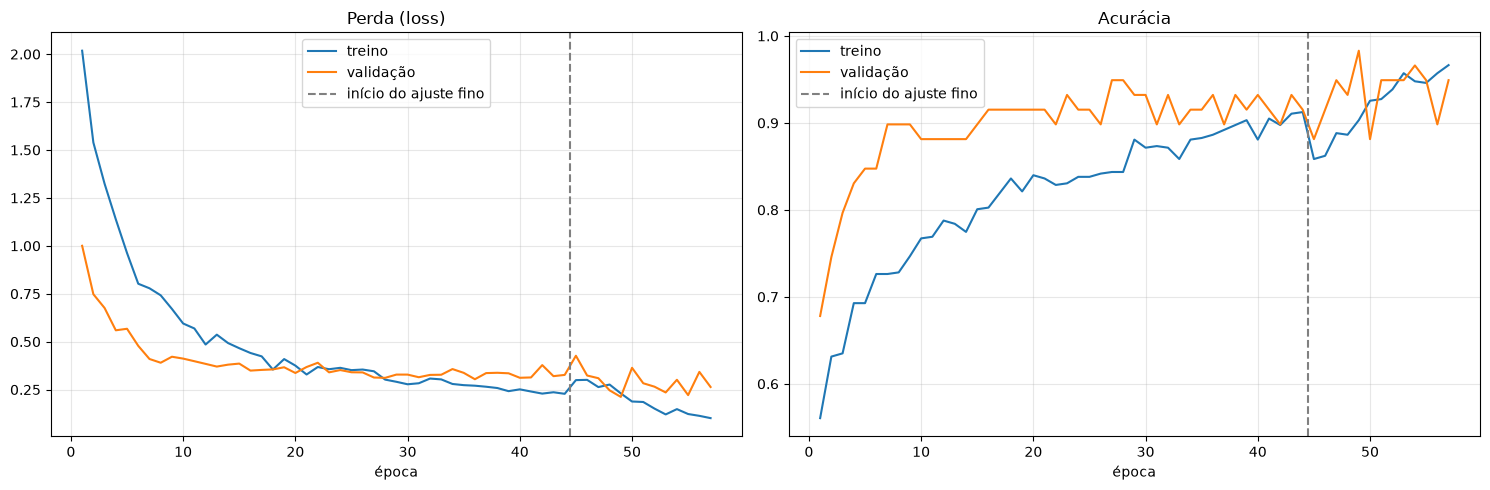

In [14]:
h = {k: historico1.history[k] + historico2.history[k] for k in historico1.history}
epocas = range(1, len(h["loss"]) + 1)

fig, (eixo_perda, eixo_acc) = plt.subplots(1, 2, figsize=(15, 5))
eixo_perda.plot(epocas, h["loss"], label="treino"); eixo_perda.plot(epocas, h["val_loss"], label="validação")
eixo_acc.plot(epocas, h["accuracy"], label="treino"); eixo_acc.plot(epocas, h["val_accuracy"], label="validação")
for eixo, titulo in [(eixo_perda, "Perda (loss)"), (eixo_acc, "Acurácia")]:
    eixo.axvline(epoca_inicial + 0.5, color="gray", linestyle="--", label="início do ajuste fino")
    eixo.set_title(titulo); eixo.set_xlabel("época"); eixo.legend(); eixo.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Avaliação no conjunto de teste

Agora, a **prova final**: as 150 imagens de teste, que o modelo **nunca viu**. Para cada imagem, o modelo devolve duas probabilidades, e a classe prevista é a de maior probabilidade (`argmax`).

O **relatório de classificação** mostra, para cada classe:

- **precision** (precisão): dos casos que o modelo chamou de covid, quantos eram covid de verdade;
- **recall** (revocação): dos casos que eram covid de verdade, quantos o modelo encontrou;
- **f1-score**: um equilíbrio entre os dois.

In [15]:
probabilidades = modelo.predict(teste, verbose=0)
previsto = np.argmax(probabilidades, axis=1)
real = np.concatenate([np.argmax(r, axis=1) for _, r in teste_bruto])

print(classification_report(real, previsto, target_names=CLASSES, digits=3))

              precision    recall  f1-score   support

       covid      0.850     0.739     0.791        69
      normal      0.800     0.889     0.842        81

    accuracy                          0.820       150
   macro avg      0.825     0.814     0.816       150
weighted avg      0.823     0.820     0.818       150



### Matriz de confusão, sensibilidade e especificidade

A **matriz de confusão** cruza a classe real (linhas) com a prevista (colunas). Na diagonal ficam os acertos; fora dela, os erros.

Considerando **covid como o caso "positivo"**, a matriz tem quatro casos: **verdadeiros positivos** (VP: covid detectado), **falsos negativos** (FN: covid que passou como normal), **verdadeiros negativos** (VN: normal reconhecido) e **falsos positivos** (FP: normal acusado de covid). Com eles calculamos:

| Métrica | Fórmula | Pergunta que responde |
|---|---|---|
| **Recall** (revocação) = **Sensibilidade** | VP / (VP + FN) | Dos pacientes **com** COVID-19, quantos o modelo detectou? |
| **Especificidade** | VN / (VN + FP) | Dos pacientes **sem** COVID-19, quantos foram reconhecidos como normais? |
| **Precisão** | VP / (VP + FP) | Quando o modelo diz "covid", quantas vezes acerta? |
| **Acurácia** | (VP + VN) / total | Quantos acertos no total? |

Em diagnóstico médico, o **recall (sensibilidade)** costuma ser a métrica mais importante: um recall baixo significa casos de covid deixados passar (**falsos negativos**), o erro mais perigoso. Repare que, no relatório de classificação acima, o *recall* da linha `covid` é a sensibilidade e o *recall* da linha `normal` é a especificidade.

Para comparação: os notebooks originais deste projeto chegavam a **73% a 77% de acurácia**. Os números podem variar alguns pontos a cada execução, porque o treino na GPU tem uma parte aleatória (ordem das imagens, aumento de dados, *dropout*).

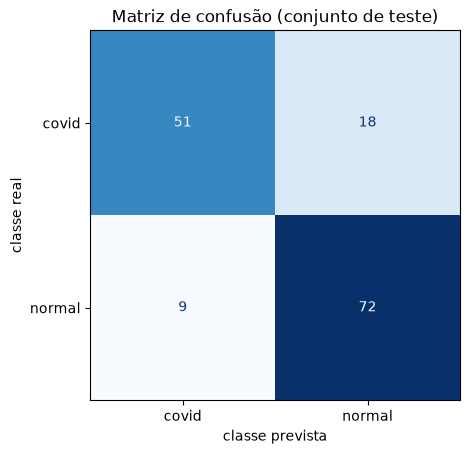

VP=51  FN=18  FP=9  VN=72

Recall (sensibilidade): 73.9%   (51 de 69 casos de covid detectados)
Especificidade:         88.9%   (72 de 81 casos normais reconhecidos)
Precisão:               85.0%   (51 de 60 alertas de covid estavam certos)
Acurácia:               82.0%   (123 de 150 imagens)


In [16]:
cm = confusion_matrix(real, previsto)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(cmap="Blues", colorbar=False)
plt.title("Matriz de confusão (conjunto de teste)")
plt.xlabel("classe prevista"); plt.ylabel("classe real")
plt.show()

VP, FN = cm[0, 0], cm[0, 1]      # linha "covid":  detectados / deixados passar
FP, VN = cm[1, 0], cm[1, 1]      # linha "normal": alarmes falsos / reconhecidos

print(f"VP={VP}  FN={FN}  FP={FP}  VN={VN}\n")
print(f"Recall (sensibilidade): {VP / (VP + FN):.1%}   ({VP} de {VP + FN} casos de covid detectados)")
print(f"Especificidade:         {VN / (VN + FP):.1%}   ({VN} de {VN + FP} casos normais reconhecidos)")
print(f"Precisão:               {VP / (VP + FP):.1%}   ({VP} de {VP + FP} alertas de covid estavam certos)")
print(f"Acurácia:               {(VP + VN) / cm.sum():.1%}   ({VP + VN} de {cm.sum()} imagens)")

## 13. Salvando o modelo treinado

O modelo treinado é salvo num único arquivo `.keras`, com a arquitetura e os pesos. Assim ele pode ser usado depois, por exemplo numa aplicação web, **sem precisar treinar de novo**. Para conferir, carregamos o arquivo e verificamos que ele dá as mesmas previsões.

In [17]:
PASTA_MODELOS.mkdir(exist_ok=True)
caminho_modelo = PASTA_MODELOS / "covid_ct_vgg16.keras"
modelo.save(caminho_modelo)
print(f"Modelo salvo em {caminho_modelo} ({caminho_modelo.stat().st_size / 1e6:.0f} MB)")

modelo_carregado = keras.models.load_model(caminho_modelo)
iguais = np.array_equal(np.argmax(modelo_carregado.predict(teste, verbose=0), axis=1), previsto)
print("Modelo carregado dá as mesmas previsões:", iguais)

Modelo salvo em modelos/covid_ct_vgg16.keras (117 MB)


Modelo carregado dá as mesmas previsões: True


## 14. Usando o modelo: previsão de uma tomografia

Por fim, o uso prático: uma função que recebe o caminho de **uma** tomografia e devolve o diagnóstico do modelo com o **grau de certeza** (a probabilidade da classe escolhida), como nos notebooks originais.

A imagem passa pelas **mesmas transformações** do treino: redimensionamento para 224×224 e `preprocess_input`. Esquecer isso na hora da previsão é outro erro comum.

In [18]:
def prever_imagem(caminho, modelo=modelo_carregado):
    imagem = keras.utils.load_img(caminho, target_size=TAMANHO_IMAGEM, color_mode="rgb")
    lote = preprocess_input(np.expand_dims(keras.utils.img_to_array(imagem), axis=0))
    prob = modelo.predict(lote, verbose=0)[0]
    classe = CLASSES[int(np.argmax(prob))]
    resultado = "COVID-19 POSITIVO" if classe == "covid" else "COVID-19 NEGATIVO (normal)"
    return resultado, float(np.max(prob)), imagem

for caminho in [teste_bruto.file_paths[0], teste_bruto.file_paths[-1]]:
    resultado, certeza, _ = prever_imagem(caminho)
    print(f"{Path(caminho).parent.name:>7}/{Path(caminho).name[:40]:<40} → {resultado} (certeza: {certeza:.1%})")

  covid/2020.01.24.919183-p27-132.png            → COVID-19 POSITIVO (certeza: 94.1%)
 normal/997.png                                  → COVID-19 NEGATIVO (normal) (certeza: 100.0%)


Para visualizar melhor, sorteamos 8 tomografias do conjunto de teste. O título mostra a classe real e a previsão do modelo: **verde** quando ele acertou, **vermelho** quando errou.

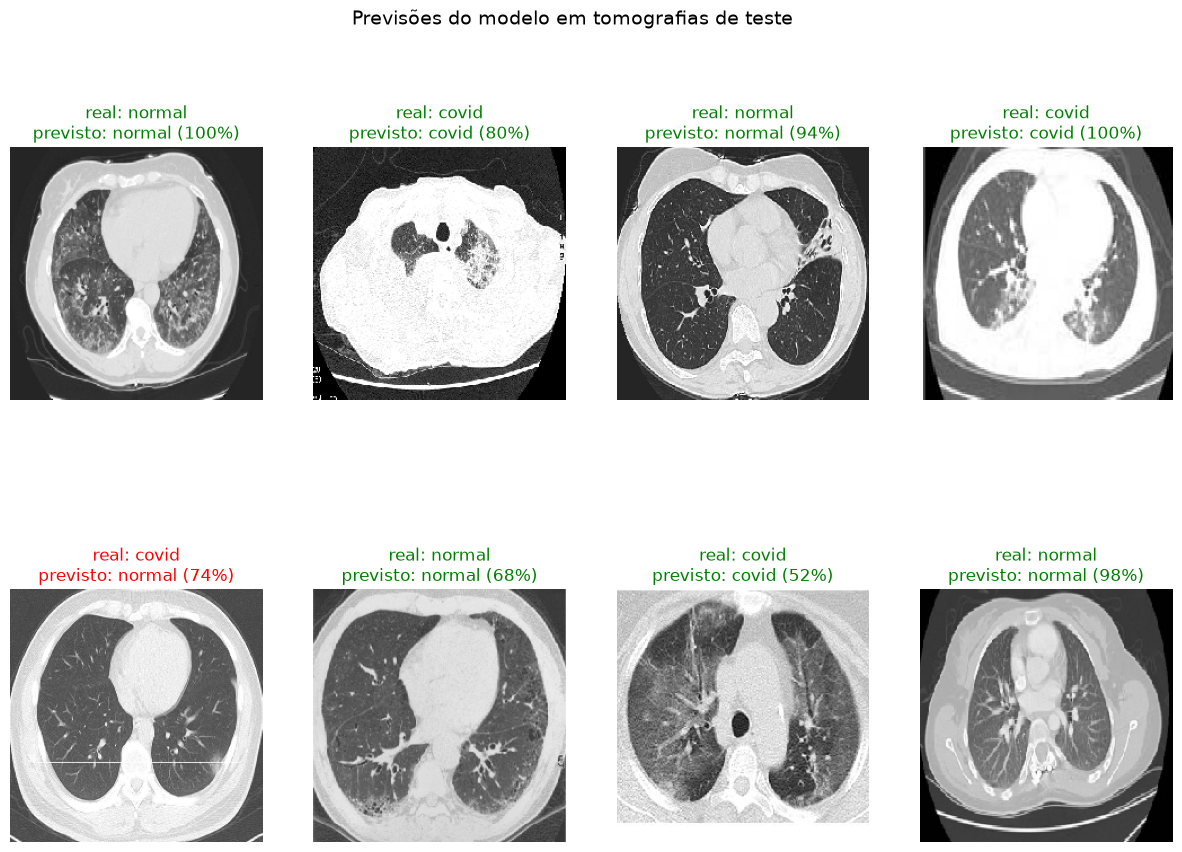

In [19]:
amostra = random.Random(7).sample(teste_bruto.file_paths, 8)
fig, eixos = plt.subplots(2, 4, figsize=(15, 10), gridspec_kw={"hspace": 0.35})
for eixo, caminho in zip(eixos.flat, amostra):
    resultado, certeza, imagem = prever_imagem(caminho)
    real_classe = Path(caminho).parent.name
    acertou = (real_classe == "covid") == resultado.startswith("COVID-19 POSITIVO")
    eixo.imshow(imagem); eixo.axis("off")
    eixo.set_title(f"real: {real_classe}\nprevisto: {'covid' if resultado.startswith('COVID-19 POSITIVO') else 'normal'} ({certeza:.0%})",
                   color="green" if acertou else "red")
plt.suptitle("Previsões do modelo em tomografias de teste", fontsize=14)
plt.show()

## 15. Resumo e exercícios

**O que fizemos:**
1. Exploramos um conjunto de tomografias de pulmão com e sem COVID-19.
2. Dividimos as imagens em **treino, validação e teste**.
3. Carregamos as imagens em lotes com `tf.data`, com **aumento de dados** e a **normalização** exigida pela VGG16.
4. Usamos **transfer learning**: a VGG16 pré-treinada no ImageNet, com uma cabeça nova.
5. Treinamos em **duas fases**: primeiro só a cabeça, depois o **ajuste fino** do último bloco.
6. Avaliamos no teste com **matriz de confusão, sensibilidade e especificidade**.
7. Salvamos o modelo e o usamos para **prever uma tomografia nova**.

**Exercícios:**
1. Troque a VGG16 pela **ResNet50** (`keras.applications.ResNet50` e o `preprocess_input` correspondente) e compare os resultados.
2. Rode sem o `preprocess_input` e veja o quanto o desempenho cai.
3. Remova o aumento de dados e observe as curvas de aprendizado: o *overfitting* aparece?
4. Descongele mais blocos da VGG16 no ajuste fino e compare.
5. Construa uma pequena aplicação web que use `prever_imagem` com o modelo salvo.